# 09 - Video Processing

Procesamiento de video por lotes, escritura incremental y resumen visual directo.


In [ ]:
from pathlib import Path
import sys

cwd = Path.cwd()
if (cwd / "vision").exists():
    PROJECT_ROOT = cwd
elif len(cwd.parents) >= 3 and (cwd.parents[2] / "vision").exists():
    PROJECT_ROOT = cwd.parents[2]
else:
    PROJECT_ROOT = cwd

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

NOTEBOOK_DIR = PROJECT_ROOT / "vision" / "yolo" / "notebooks"
OUTPUT_DIR = NOTEBOOK_DIR / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

IMAGE = (
    str(NOTEBOOK_DIR / "bus.jpg")
    if (NOTEBOOK_DIR / "bus.jpg").exists()
    else "https://ultralytics.com/images/bus.jpg"
)

from vision.yolo.video import (
    video_frame_generator,
    write_video_predictions,
    write_annotated_video,
    write_annotated_video_from_dataframe,
    get_video_info,
)
from vision.yolo.infer import predict_video
from vision.yolo.plotting import plot_video_statistics, plot_class_distribution

MODEL = (
    str(NOTEBOOK_DIR / "yolo11n.pt")
    if (NOTEBOOK_DIR / "yolo11n.pt").exists()
    else "yolo11n.pt"
)


In [ ]:
# Inspeccionar metadata de video
VIDEO = "/home/juan/Downloads/10274941-uhd_4096_2160_25fps.mp4"
info = get_video_info(VIDEO)
print(info)


{'path': '/home/juan/Downloads/10274941-uhd_4096_2160_25fps.mp4', 'width': 2732, 'height': 1440, 'fps': 25.0, 'frame_count': 919, 'duration_s': 36.76}


In [ ]:
# Iterar frames sin cargar todo el video en memoria
for frames, indices, timestamps in video_frame_generator(
    VIDEO, batch_size=8, max_frames=24
):
    print(
        f"Batch frames={indices[0]}..{indices[-1]} shape={frames[0].shape} ts={timestamps[0]:.2f}"
    )


Batch frames=0..7 shape=(1440, 2732, 3) ts=0.00
Batch frames=8..15 shape=(1440, 2732, 3) ts=0.32
Batch frames=16..23 shape=(1440, 2732, 3) ts=0.64


In [ ]:
# Inferencia por video con escritura incremental a parquet
df = predict_video(
    MODEL,
    VIDEO,
    confidence=0.25,
    batch_size=8,
    save_to=OUTPUT_DIR / "09_predictions.parquet",
)
print(df.head())


/home/juan/miniforge3/envs/ultralytics/lib/python3.12/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


   frame track_id  class_id class_name  confidence         xmin        ymin  \
0      0     None         0     person    0.902791  1637.768433  283.583679   
1      0     None         0     person    0.900629  1026.129517  432.052429   
2      0     None         0     person    0.887594   622.736511  220.808426   
3      1     None         0     person    0.907346  1639.014282  283.954926   
4      1     None         0     person    0.902552  1025.285034  431.792664   

          xmax         ymax polygon  mask keypoints  timestamp  
0  1938.268677   871.658264    None  None      None       0.00  
1  1464.242065  1126.025391    None  None      None       0.00  
2   887.238098   848.676086    None  None      None       0.00  
3  1940.615479   872.869324    None  None      None       0.04  
4  1454.686279  1125.572266    None  None      None       0.04  


In [ ]:
# Crear un video anotado desde el DataFrame ya generado por predict_video
# No vuelve a correr el modelo: usa df o el parquet guardado en la celda anterior.
# annotated_from_df = write_annotated_video_from_dataframe(
#     video_path=VIDEO,
#     predictions=df,  # tambien puede ser OUTPUT_DIR / "09_predictions.parquet"
#     output_path=OUTPUT_DIR / "09_annotated_from_dataframe.mp4",
#     color_by="confidence",  # "class", "track_id" o "confidence"
#     draw_boxes=True,
#     draw_labels=True,
#     draw_polygons=True,
#     draw_keypoints=True,
#     draw_tails=False,  # usar True si df viene de tracking y tiene track_id
# )
# print(annotated_from_df)


In [ ]:
# Alternativa que puede usar tracker y escribir parquet/csv/feather
output_path = write_video_predictions(
    model_path=MODEL,
    video_path=VIDEO,
    output_path=OUTPUT_DIR / "09_video_predictions.parquet",
    tracker=None,
    batch_size=8,
)
print(output_path)


/home/juan/Documents/GitHub/ultrawrapper/vision/yolo/notebooks/outputs/09_video_predictions.parquet


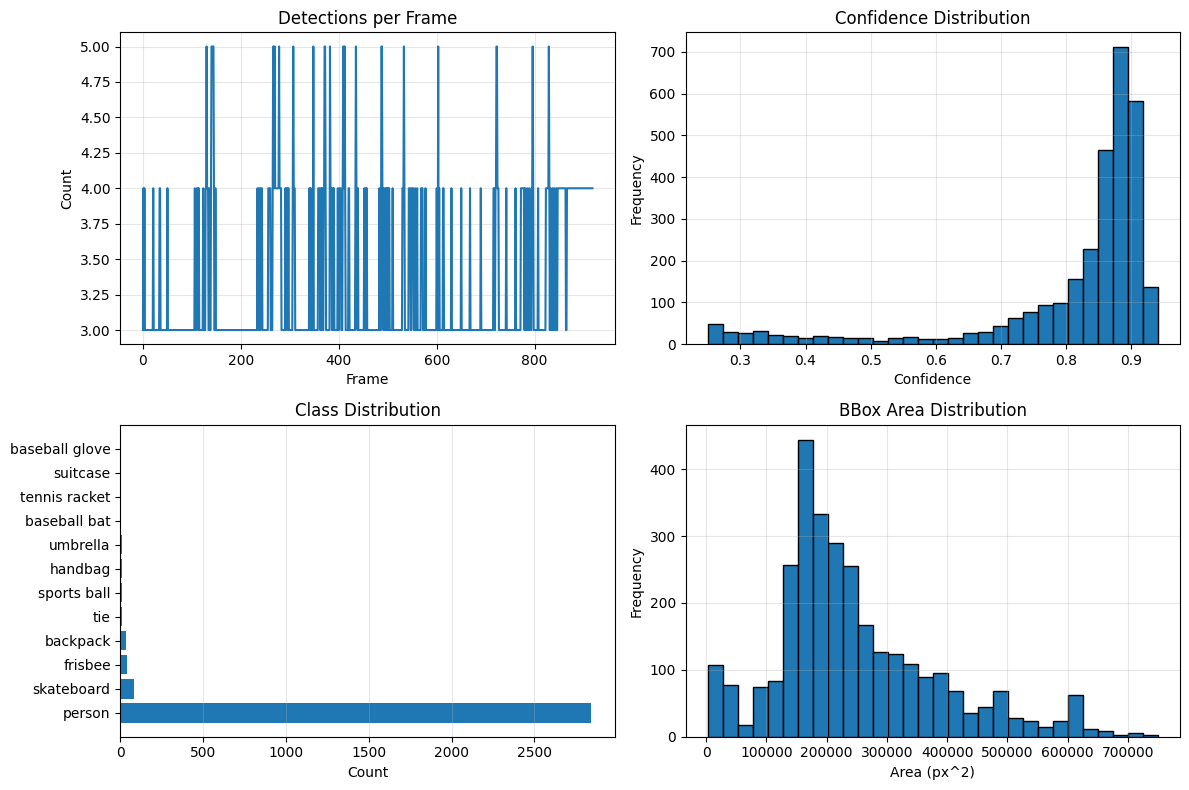

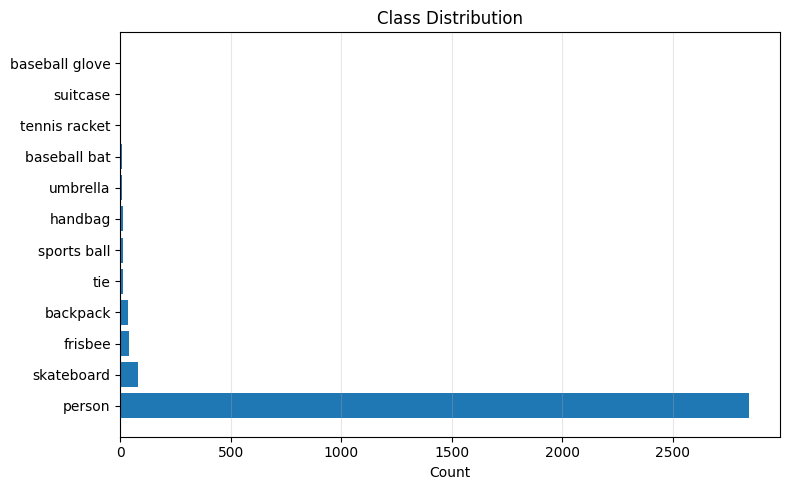

In [ ]:
# Resumenes visuales directos
plot_video_statistics(df, save_to=OUTPUT_DIR / "09_video_statistics.png")
plot_class_distribution(df, save_to=OUTPUT_DIR / "09_video_classes.png")


In [ ]:
# Escribir video anotado con predicciones superpuestas
# Usa tracker si queres track_id y trailing/tails coherentes entre frames.
from vision.yolo.video import write_annotated_video

annotated_path, annotated_df = write_annotated_video(
     model_path=MODEL,
     video_path=VIDEO,
     output_path=OUTPUT_DIR / "09_annotated_video.mp4",
     tracker="bytetrack.yaml",
     color_by="confidence",  # "class", "track_id" o "confidence"
     draw_tails=True,
     tail_length=30,
     draw_boxes=True,
     draw_labels=True,
     draw_polygons=True,
     draw_keypoints=True,
     save_predictions_to=OUTPUT_DIR / "09_annotated_predictions.parquet",
     return_predictions=True,
)
print(annotated_path)
print(annotated_df.head())
